## Phase 1: Business Understanding

## Project Title
Student Placement Prediction System

## Business Context
Campus placement is an important outcome for students, colleges and recruiters. Placement cells maintain student academic records, specialization, work experience and employability test scores, but these records are often not used for predictive decision-making.

This project uses machine learning to predict whether a student is likely to be placed or not based on academic and employability-related information.

## Problem Statement
The placement cell needs a data-driven system to identify students who are likely to be placed and students who may require additional support before campus recruitment.

Manual judgement may miss important patterns in academic performance, specialization, work experience and employability scores. A machine learning model can help identify placement readiness more systematically.

## Objective
The objective of this project is to build an end-to-end machine learning pipeline that predicts student placement status as Placed or Not Placed.

The system will:
- Analyze student placement data
- Identify important factors influencing placement
- Handle missing values and categorical variables
- Build and compare machine learning models
- Optimize the best-performing model
- Deploy the model using Streamlit

## Why Placement Prediction Matters
Placement prediction matters because it helps institutions identify students who need early support. Instead of waiting until final placement season, colleges can use data to guide students through aptitude training, interview preparation, communication improvement and resume building.

## College and HR Analytics Use Case
For colleges, this system can help the placement cell classify students into high-readiness, moderate-readiness and support-required categories.

For HR analytics, this type of system can help understand which academic and employability factors are linked with successful placement outcomes.

## Business Impact
This project can help:
- Improve student employability planning
- Support targeted training programs
- Improve placement-cell decision-making
- Identify weak areas in student profiles
- Improve college placement outcomes

## Ethical Note
The prediction should support human decision-making and should not be used as a final judgement on any student. It should be used as an advisory tool for student improvement.

## Data Understanding and EDA

In [1]:
#Importing  Libraries and Theme
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

purple = "#4B145F"
teal = "#178F83"
red = "#D95C59"
gold = "#F2A900"
blue = "#20639B"
grey = "#6C757D"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv("C:/Users/HP/Desktop/dataset ML 1.csv")
print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 7500
Columns: 15


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,69.12,Others,65.00,Others,Commerce,65.67,Others,No,73.05,Mkt&HR,65.30,Placed,310000.0
1,2,F,75.26,Others,73.32,Central,Commerce,58.43,Comm&Mgmt,Yes,62.95,Business Analytics,55.78,Not Placed,NaN
2,3,M,83.87,Central,60.77,Others,Science,61.93,Sci&Tech,No,NaN,Business Analytics,57.41,Placed,295000.0
3,4,M,90.41,Central,86.27,Others,Commerce,78.05,Comm&Mgmt,No,76.96,Mkt&HR,60.74,Placed,290000.0
4,5,M,74.64,Others,76.05,Central,Commerce,73.96,Comm&Mgmt,No,81.03,Business Analytics,59.89,Placed,345000.0


In [3]:
column_audit = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Values": df.notna().sum(),
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

column_audit

,Column,Data Type,Non-Null Values,Missing Values,Missing Percentage,Unique Values
sl_no,sl_no,int64,7500,0,0.00,7500
gender,gender,object,7500,0,0.00,2
ssc_p,ssc_p,float64,7500,0,0.00,3390
ssc_b,ssc_b,object,7500,0,0.00,2
hsc_p,hsc_p,float64,7425,75,1.00,3397
hsc_b,hsc_b,object,7470,30,0.40,2
hsc_s,hsc_s,object,7500,0,0.00,3
degree_p,degree_p,float64,7448,52,0.69,2644
degree_t,degree_t,object,7500,0,0.00,3
workex,workex,object,7470,30,0.40,2


In [4]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]
missing_summary.sort_values("Missing Percentage", ascending=False)

,Missing Values,Missing Percentage
salary,2718,36.24
etest_p,90,1.20
hsc_p,75,1.00
mba_p,60,0.80
degree_p,52,0.69
hsc_b,30,0.40
workex,30,0.40


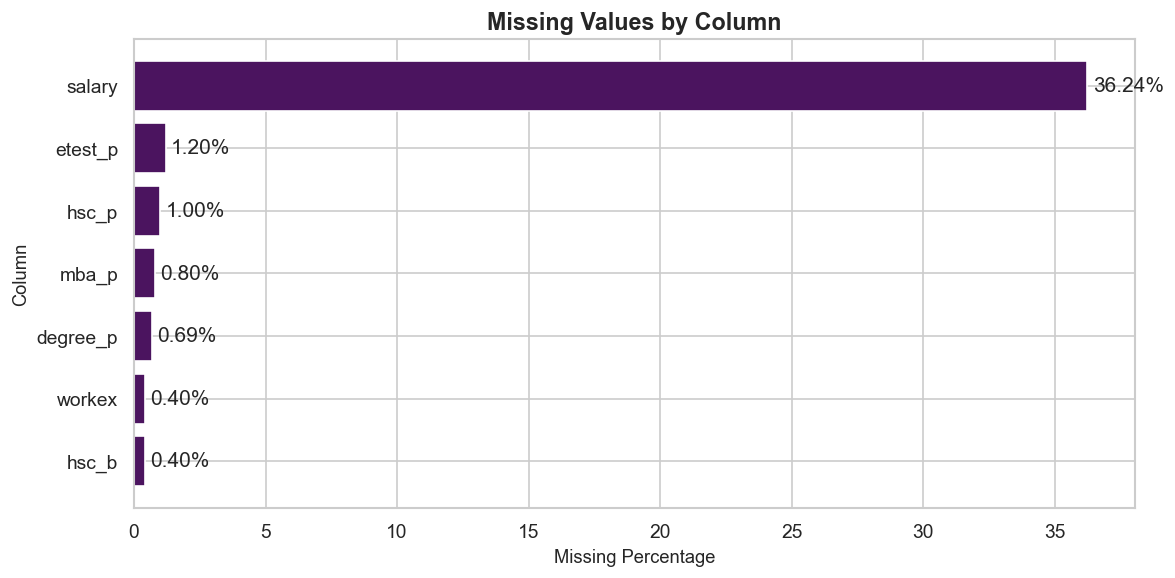

In [5]:
missing_plot = missing_summary.sort_values("Missing Percentage")

plt.figure(figsize=(10, 5))

plt.barh(
    missing_plot.index,
    missing_plot["Missing Percentage"],
    color=purple
)

for index, value in enumerate(missing_plot["Missing Percentage"]):
    plt.text(value + 0.2, index, f"{value:.2f}%", va="center")

plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [6]:
salary_check = pd.crosstab(
    df["status"],
    df["salary"].isna(),
    margins=True
)

salary_check.columns = ["Salary Available", "Salary Missing", "Total"]
salary_check

,Salary Available,Salary Missing,Total
status,,,
Not Placed,0,2718,2718
Placed,4782,0,4782
All,4782,2718,7500


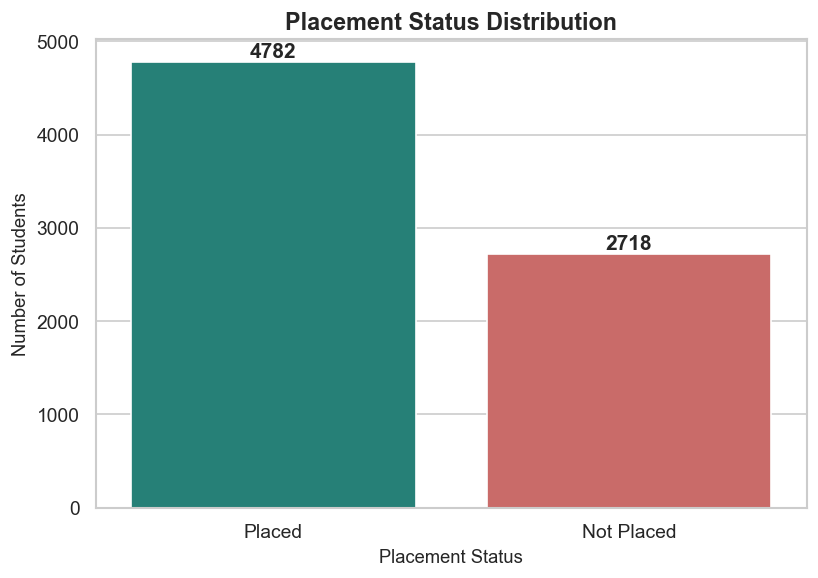

status
Placed        63.76
Not Placed    36.24
Name: proportion, dtype: float64

In [7]:
status_counts = df["status"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    palette=[teal, red]
)

for i, value in enumerate(status_counts.values):
    plt.text(i, value + 50, str(value), ha="center", fontweight="bold")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

status_percentage = (df["status"].value_counts(normalize=True) * 100).round(2)
status_percentage

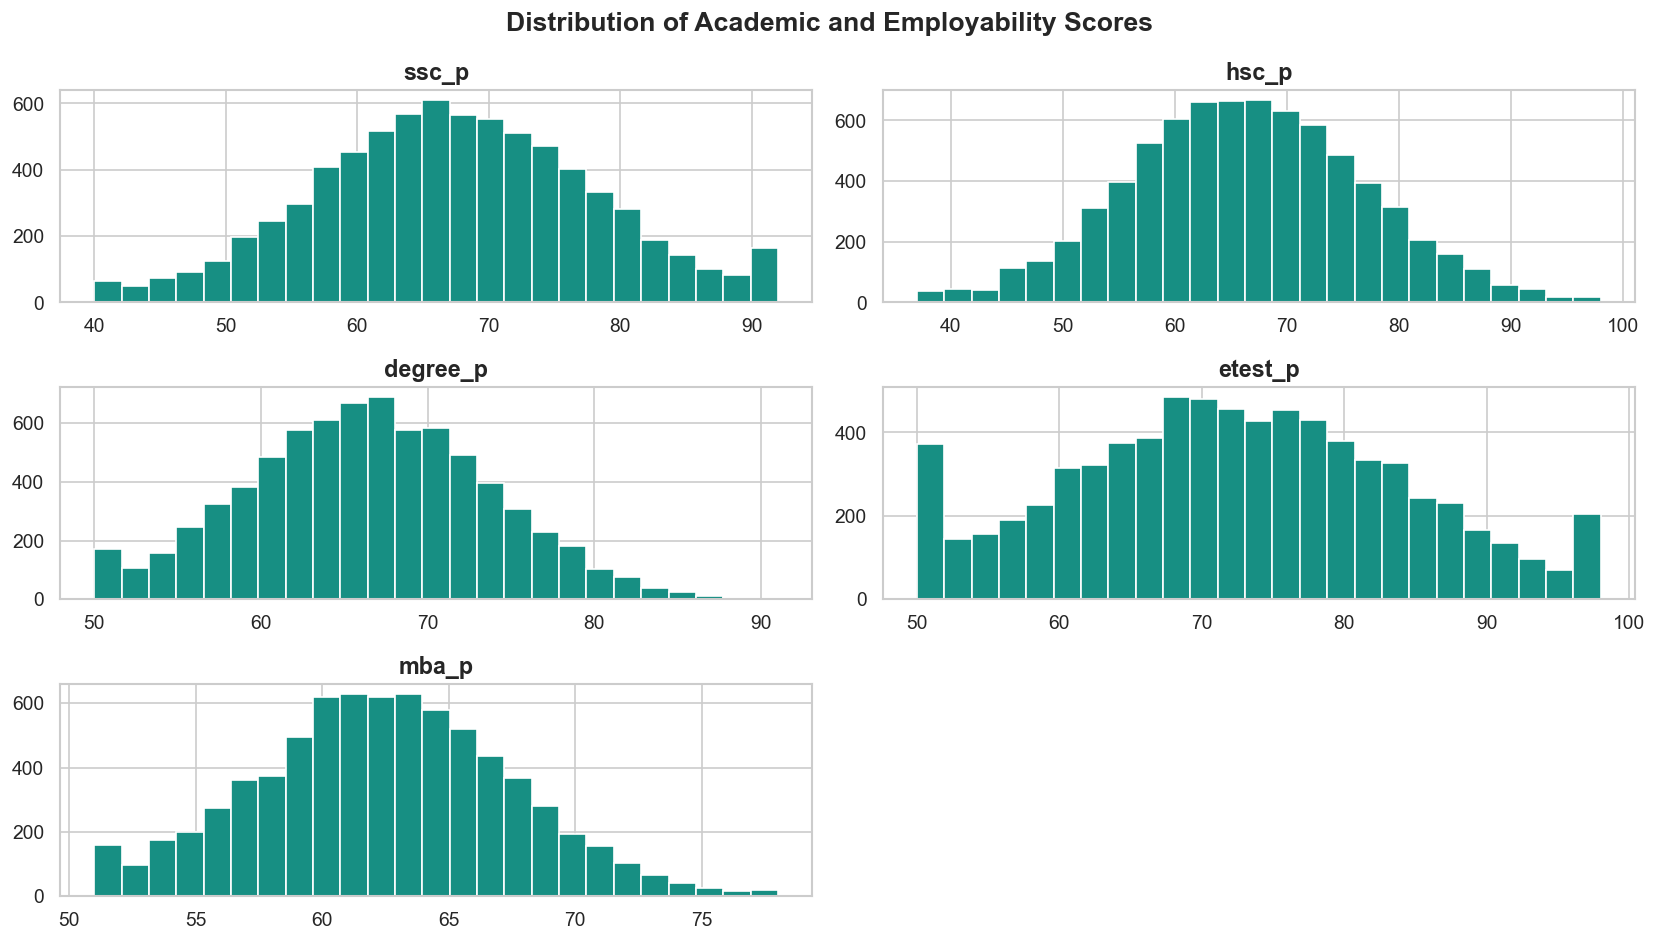

In [8]:
score_columns = ["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p"]

df[score_columns].hist(
    figsize=(14, 8),
    bins=25,
    color=teal,
    edgecolor="white"
)

plt.suptitle("Distribution of Academic and Employability Scores", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

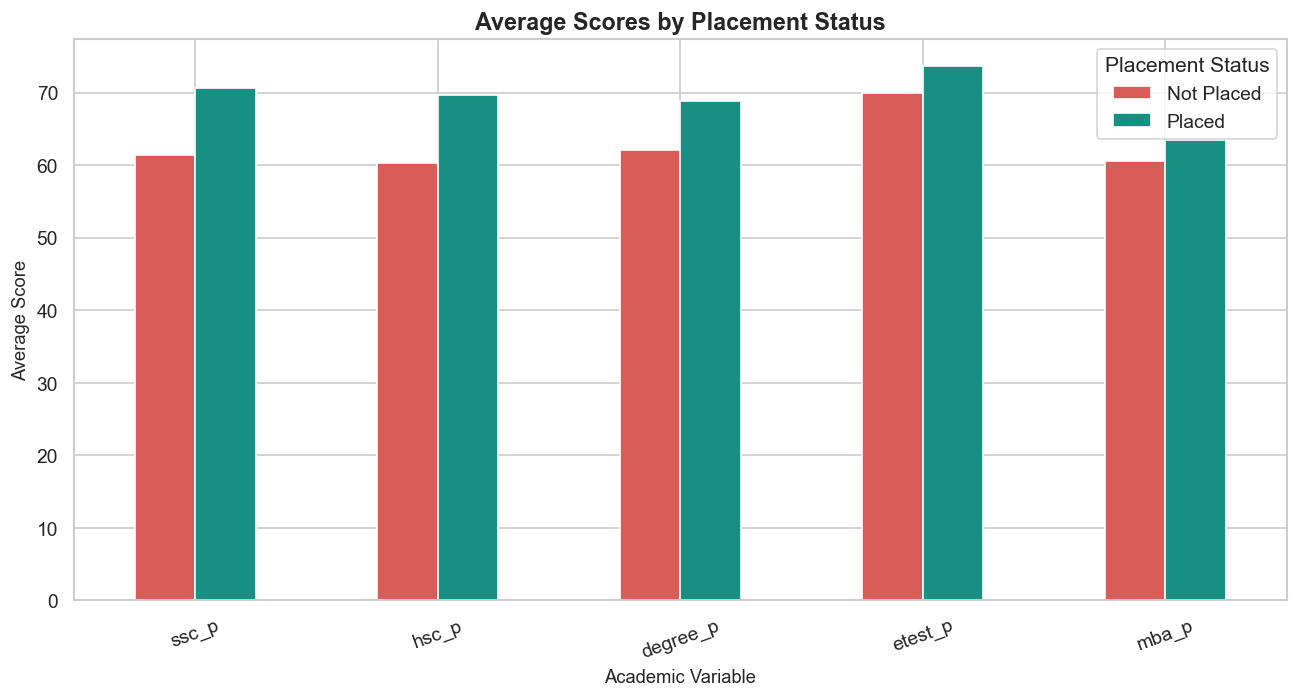

status,Not Placed,Placed
ssc_p,61.47,70.72
hsc_p,60.28,69.72
degree_p,62.06,68.89
etest_p,69.95,73.68
mba_p,60.56,63.42


In [9]:
average_scores = df.groupby("status")[score_columns].mean().T.round(2)

average_scores.plot(
    kind="bar",
    figsize=(11, 6),
    color=[red, teal]
)

plt.title("Average Scores by Placement Status")
plt.xlabel("Academic Variable")
plt.ylabel("Average Score")
plt.xticks(rotation=20)
plt.legend(title="Placement Status")
plt.tight_layout()
plt.show()

average_scores

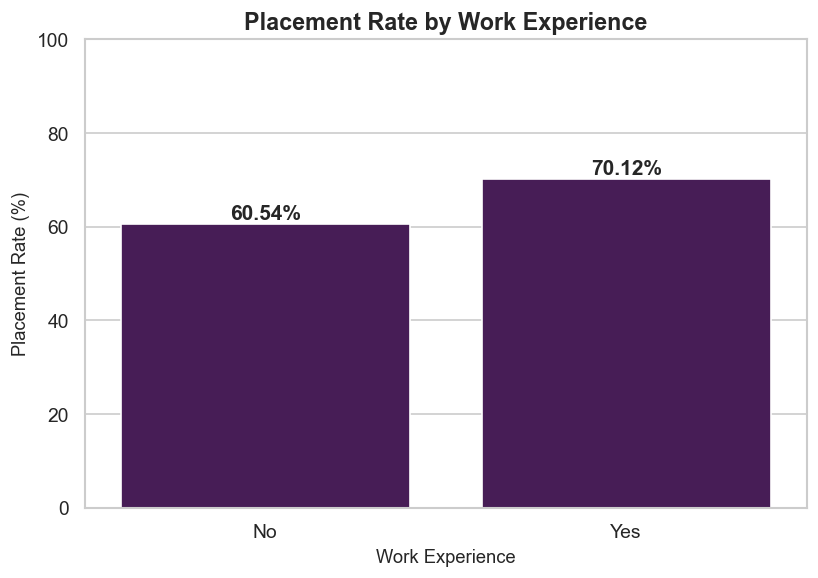

workex
No     60.54
Yes    70.12
Name: status, dtype: float64

In [10]:


workex_rate = (
    df.groupby("workex")["status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
    .round(2)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=workex_rate.index,
    y=workex_rate.values,
    color=purple
)

for i, value in enumerate(workex_rate.values):
    plt.text(i, value + 1, f"{value}%", ha="center", fontweight="bold")

plt.title("Placement Rate by Work Experience")
plt.xlabel("Work Experience")
plt.ylabel("Placement Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

workex_rate

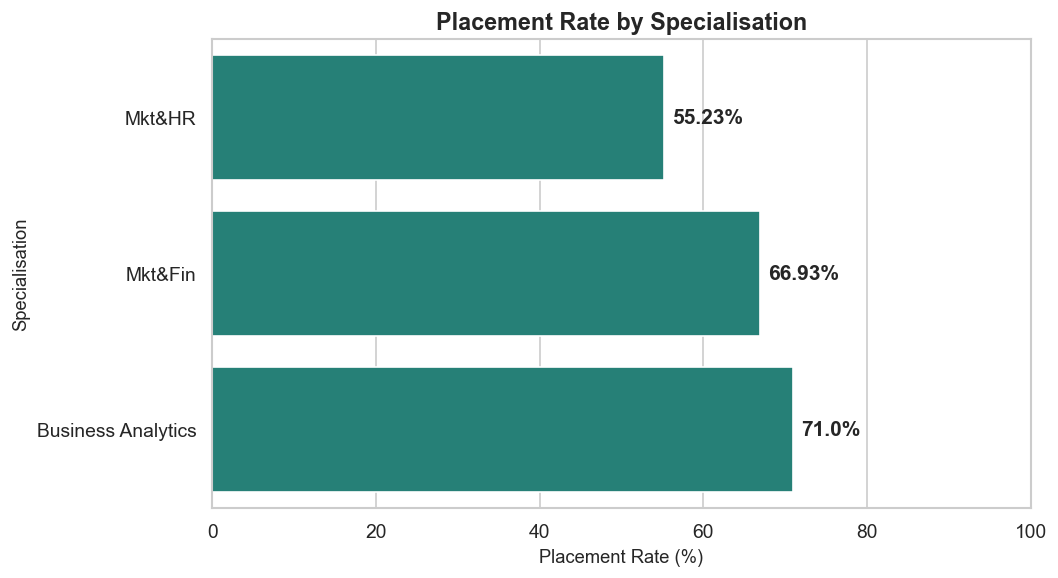

specialisation
Mkt&HR                55.23
Mkt&Fin               66.93
Business Analytics    71.00
Name: status, dtype: float64

In [11]:
specialisation_rate = (
    df.groupby("specialisation")["status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
    .sort_values()
    .round(2)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=specialisation_rate.values,
    y=specialisation_rate.index,
    color=teal
)

for i, value in enumerate(specialisation_rate.values):
    plt.text(value + 1, i, f"{value}%", va="center", fontweight="bold")

plt.title("Placement Rate by Specialisation")
plt.xlabel("Placement Rate (%)")
plt.ylabel("Specialisation")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

specialisation_rate

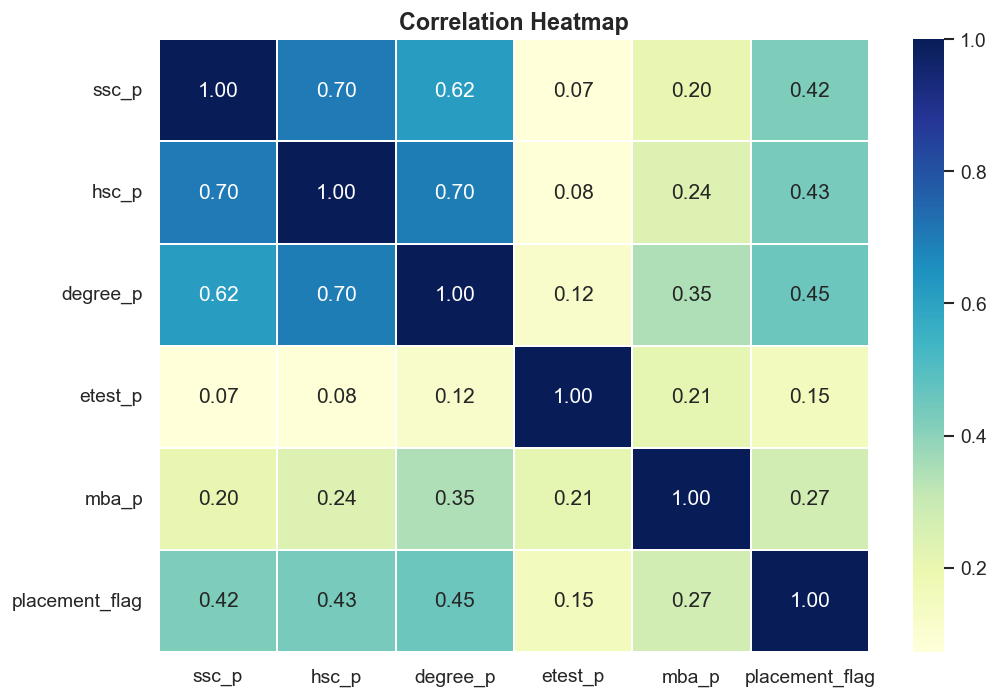

degree_p    0.454361
hsc_p       0.434550
ssc_p       0.421508
mba_p       0.273818
etest_p     0.153396
Name: placement_flag, dtype: float64

In [12]:
correlation_df = df.copy()

correlation_df["placement_flag"] = correlation_df["status"].map({
    "Not Placed": 0,
    "Placed": 1
})

corr_columns = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p",
    "placement_flag"
]

corr_matrix = correlation_df[corr_columns].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="YlGnBu",
    linewidths=1,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

corr_matrix["placement_flag"].drop("placement_flag").sort_values(ascending=False)

## Phase 3: Data Preprocessing

In [13]:
features = [
    "gender",
    "ssc_p",
    "ssc_b",
    "hsc_p",
    "hsc_b",
    "hsc_s",
    "degree_p",
    "degree_t",
    "workex",
    "etest_p",
    "specialisation",
    "mba_p"
]

target = "status"

X = df[features]
y = df[target]

print("Features selected:", X.shape[1])
print("Target selected:", target)

Features selected: 12
Target selected: status


In [14]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train_raw.shape)
print("Testing data:", X_test_raw.shape)

Training data: (6000, 12)
Testing data: (1500, 12)


## Phase 4: Feature Engineering and Selection

In [15]:
def create_features(data):
    data = data.copy()
    
    data["academic_average"] = data[["ssc_p", "hsc_p", "degree_p", "mba_p"]].mean(axis=1)
    
    data["employability_average"] = data[["degree_p", "etest_p", "mba_p"]].mean(axis=1)
    
    data["academic_growth"] = data["degree_p"] - data["ssc_p"]
    
    data["low_score_count"] = (
        (data["ssc_p"] < 60).astype(int) +
        (data["hsc_p"] < 60).astype(int) +
        (data["degree_p"] < 60).astype(int) +
        (data["etest_p"] < 60).astype(int) +
        (data["mba_p"] < 60).astype(int)
    )
    
    return data

In [16]:
X_train = create_features(X_train_raw)
X_test = create_features(X_test_raw)

X_train.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,academic_average,employability_average,academic_growth,low_score_count
4752,M,63.11,Central,73.77,Others,Science,58.99,Others,No,50.00,Business Analytics,67.63,65.8750,58.873333,-4.12,2
3183,M,60.83,Central,64.66,Others,Science,60.15,Sci&Tech,Yes,64.83,Business Analytics,67.40,63.2600,64.126667,-0.68,0
3439,F,66.54,Others,71.85,Central,Arts,64.90,Comm&Mgmt,No,73.79,Mkt&Fin,60.13,65.8550,66.273333,-1.64,0
4348,M,76.72,Others,69.84,Others,Commerce,79.16,Comm&Mgmt,Yes,86.63,Mkt&Fin,57.73,70.8625,74.506667,2.44,1
6742,M,72.31,Others,81.69,Central,Science,70.92,Sci&Tech,No,58.16,Mkt&HR,58.99,70.9775,62.690000,-1.39,2


In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_columns = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p",
    "academic_average",
    "employability_average",
    "academic_growth",
    "low_score_count"
]

categorical_columns = [
    "gender",
    "ssc_b",
    "hsc_b",
    "hsc_s",
    "degree_t",
    "workex",
    "specialisation"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Model Building

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    model_pipeline.fit(X_train, y_train)
    
    predictions = model_pipeline.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, pos_label="Placed"),
        "Recall": recall_score(y_test, predictions, pos_label="Placed"),
        "F1 Score": f1_score(y_test, predictions, pos_label="Placed")
    })
    
    trained_models[name] = model_pipeline

model_results = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.7500,0.7908,0.8264,0.8082
0,Logistic Regression,0.7473,0.8414,0.7437,0.7896
1,Decision Tree,0.7107,0.8063,0.7186,0.7600


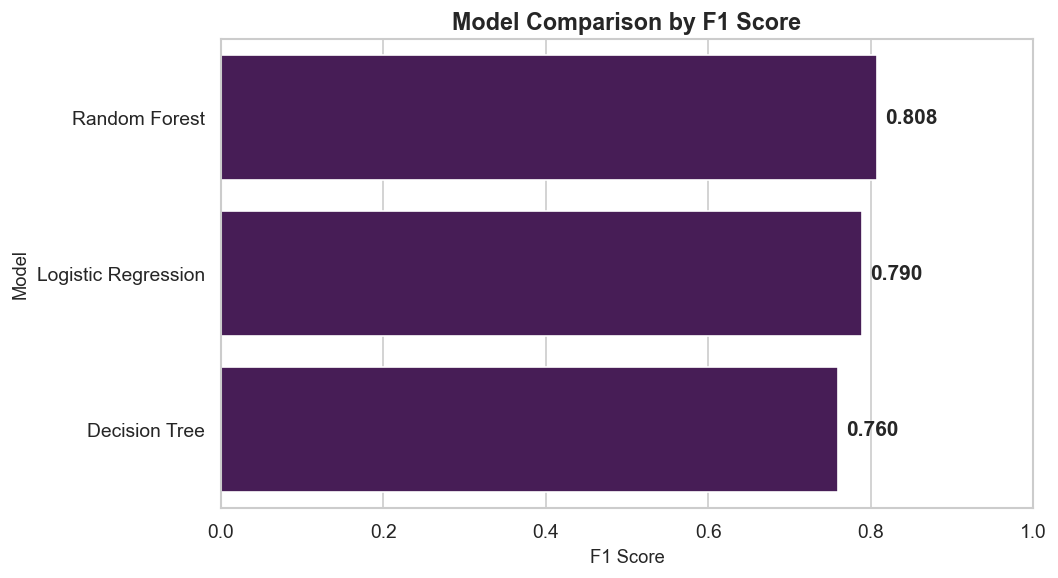

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="F1 Score",
    y="Model",
    color=purple
)

for i, value in enumerate(model_results["F1 Score"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center", fontweight="bold")

plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

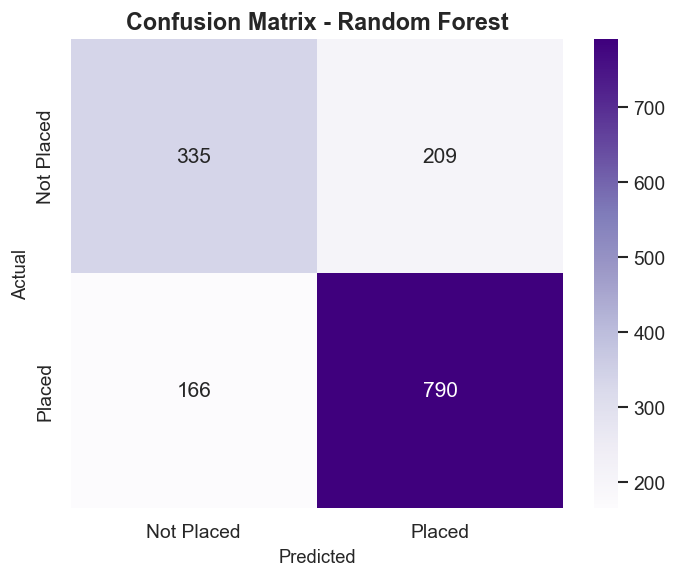

Best Model: Random Forest
              precision    recall  f1-score   support

  Not Placed       0.67      0.62      0.64       544
      Placed       0.79      0.83      0.81       956

    accuracy                           0.75      1500
   macro avg       0.73      0.72      0.72      1500
weighted avg       0.75      0.75      0.75      1500



In [20]:
from sklearn.metrics import confusion_matrix, classification_report

best_model_name = model_results.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=["Not Placed", "Placed"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Best Model:", best_model_name)
print(classification_report(y_test, best_predictions))

## Phase 6: Model Optimization

In [21]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])

parameters = {
    "model__n_estimators": [80, 100, 120],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_leaf": [2, 3, 5]
}

search = RandomizedSearchCV(
    rf_pipeline,
    parameters,
    n_iter=6,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

final_model = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

Best Parameters:
{'model__n_estimators': 80, 'model__min_samples_leaf': 2, 'model__max_depth': 8}


In [22]:
final_predictions = final_model.predict(X_test)

final_scores = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, final_predictions),
        precision_score(y_test, final_predictions, pos_label="Placed"),
        recall_score(y_test, final_predictions, pos_label="Placed"),
        f1_score(y_test, final_predictions, pos_label="Placed")
    ]
})

final_scores.round(4)

,Metric,Score
0,Accuracy,0.7360
1,Precision,0.8125
2,Recall,0.7615
3,F1 Score,0.7862


In [23]:
import joblib
import os

joblib.dump(final_model, "model.pkl", compress=9)

print("Model saved successfully as model.pkl")
print("Model size MB:", round(os.path.getsize("model.pkl") / (1024 * 1024), 2))

Model saved successfully as model.pkl
Model size MB: 0.75


In [24]:
import sklearn
print(sklearn.__version__)


1.7.2


In [25]:
import sys
import sklearn
import numpy
import scipy
import pandas
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.7.2
numpy: 2.3.5
scipy: 1.16.3
pandas: 2.3.3
joblib: 1.5.2


In [26]:
import joblib
import os

joblib.dump(
    final_model,
    "model.pkl",
    compress=3
)

print("New model.pkl created successfully")
print(
    "Model size:",
    round(os.path.getsize("model.pkl") / (1024 * 1024), 2),
    "MB"
)

New model.pkl created successfully
Model size: 0.8 MB


In [27]:
test_model = joblib.load("model.pkl")

test_prediction = test_model.predict(X_test.head(1))

print("Model loaded successfully")
print("Test prediction:", test_prediction)

Model loaded successfully
Test prediction: ['Not Placed']
